# COE 311K Final Project: Numerical Solution of a Spring-Mass Vehicle Suspension System

Name: Yareli Flores  
EID: yf4765  
Individual Project

## 1. Introduction and Model Selection

For this project, I chose to model a vehicle suspension system using a damped spring-mass system. A car suspension is a good real-world example because it contains a mass, a spring, and a damper. The mass represents the supported vehicle body, the spring represents the suspension stiffness, and the damper represents the shock absorber. When a vehicle hits a bump, the suspension is displaced from equilibrium and then oscillates while the damper gradually removes energy from the system.

The governing second-order differential equation is

m y'' + c y' + k y = 0

where m is the sprung mass, c is the damping coefficient, k is the spring constant, and y(t) is the vertical displacement from equilibrium.

Dividing by m gives

y'' = -(c/m)y' - (k/m)y

To solve this numerically, the second-order ODE is converted into a system of two first-order ODEs. Let

y1 = y  
y2 = y'

Then

dy1/dt = y2  
dy2/dt = -(c/m)y2 - (k/m)y1

This first-order system is used for both Euler's Forward method and the fourth-order Runge-Kutta method.

## 2. Parameter Research and Justification

This project models one quarter of a passenger vehicle suspension system. A quarter-car model is commonly used because it simplifies the full vehicle into one wheel and the portion of the vehicle body supported by that wheel. The selected parameter values are based on published quarter-car suspension model values for a simple passenger car.

| Parameter | Symbol | Value | Units | Source / Justification |
|---|---:|---:|---|---|
| Sprung mass | m | 290 | kg | Quarter-car passenger vehicle sprung mass |
| Damping coefficient | c | 1000 | N·s/m | Passenger-car suspension damping coefficient |
| Spring constant | k | 16812 | N/m | Passenger-car suspension spring stiffness |
| Initial displacement | y(0) | 0.10 | m | Represents suspension displacement after hitting a bump |
| Initial velocity | y'(0) | 0 | m/s | Car body is released from rest after the bump |

The initial condition y(0) = 0.10 m represents the car body being displaced 10 cm from equilibrium after a bump. The initial velocity y'(0) = 0 m/s means the body starts from rest at the displaced position. The simulation interval is 0 to 5 seconds, which is long enough to observe the damped oscillations decay.

The values m = 290 kg, c = 1000 N·s/m, and k = 16812 N/m are commonly reported quarter-car passenger vehicle parameters.

References:
[1] “Simulation and Analysis of Passive and Active Suspension System Using Quarter Car Model,” IJETT, quarter-car model parameters: M2 = 290 kg, Ka = 16812 N/m, Ca = 1000 Ns/m.
[2] Şenaslan and Bilgiç, “Control of the Quarter Vehicle Model with an Innovative Delayed Resonator Optimized by Genetic Algorithm,” 2024, Table 1 quarter-car parameters.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

m = 290
c = 1000
k = 16812

y0 = 0.10
v0 = 0.0

t0 = 0
tf = 5

def suspension_rhs(t, state):
    y1, y2 = state
    dy1dt = y2
    dy2dt = -(c / m) * y2 - (k / m) * y1
    return np.array([dy1dt, dy2dt])

def euler_forward(f, t0, tf, h, initial_state):
    t = np.arange(t0, tf + h, h)
    state = np.zeros((len(t), len(initial_state)))
    state[0] = initial_state
    
    for i in range(len(t) - 1):
        state[i + 1] = state[i] + h * f(t[i], state[i])
    
    return t, state

def rk4(f, t0, tf, h, initial_state):
    t = np.arange(t0, tf + h, h)
    state = np.zeros((len(t), len(initial_state)))
    state[0] = initial_state
    
    for i in range(len(t) - 1):
        k1 = f(t[i], state[i])
        k2 = f(t[i] + h / 2, state[i] + h * k1 / 2)
        k3 = f(t[i] + h / 2, state[i] + h * k2 / 2)
        k4 = f(t[i] + h, state[i] + h * k3)
        
        state[i + 1] = state[i] + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    
    return t, state

def analytical_solution(t):
    alpha = c / (2 * m)
    omega_n = np.sqrt(k / m)
    omega_d = np.sqrt(omega_n**2 - alpha**2)
    
    A = y0
    B = (v0 + alpha * y0) / omega_d
    
    y = np.exp(-alpha * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))
    
    v = np.exp(-alpha * t) * (
        -alpha * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))
        + (-A * omega_d * np.sin(omega_d * t) + B * omega_d * np.cos(omega_d * t))
    )
    
    return y, v

initial_state = np.array([y0, v0])
h_values = [0.1, 0.05, 0.01]

## 3. Numerical Methods Implementation

Two numerical methods were implemented: Euler's Forward method and the fourth-order Runge-Kutta method. Euler's Forward method estimates the next point using the slope at the current point, so it is simple but only first-order accurate. RK4 uses four slope estimates at each time step and combines them with weighted averaging, making it much more accurate for the same step size.

Both methods use the same first-order system:

dy1/dt = y2  
dy2/dt = -(c/m)y2 - (k/m)y1

The functions were written modularly so that the right-hand side of the ODE system is separated from the numerical method. This makes the code easier to check, reuse, and compare.

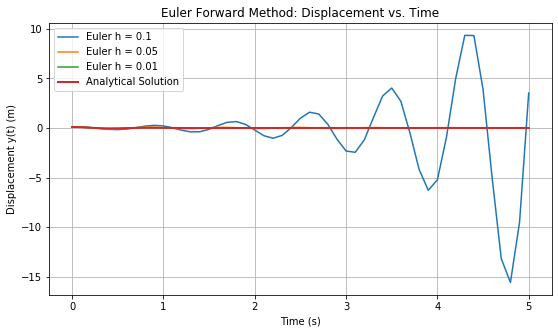

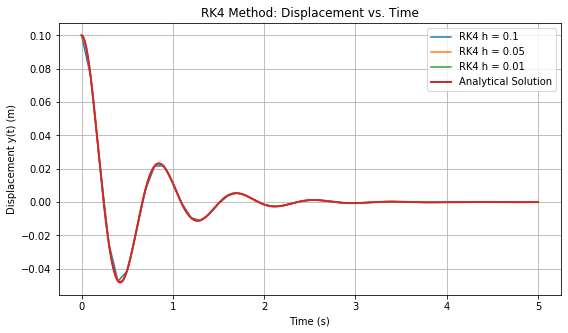

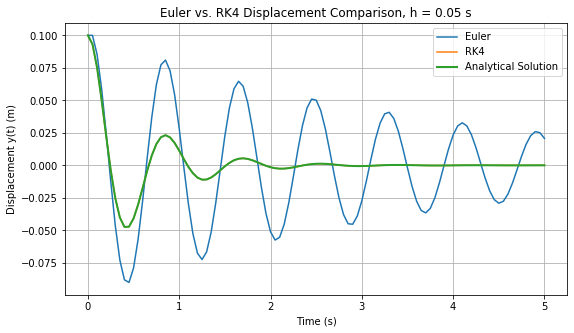

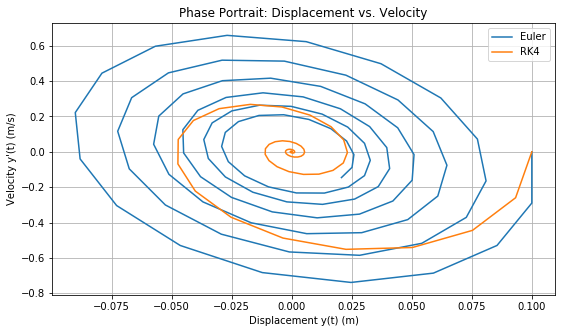

In [10]:
plt.figure(figsize=(9, 5))

for h in h_values:
    t_euler, state_euler = euler_forward(suspension_rhs, t0, tf, h, initial_state)
    plt.plot(t_euler, state_euler[:, 0], label=f"Euler h = {h}")

t_exact = np.linspace(t0, tf, 1000)
y_exact, v_exact = analytical_solution(t_exact)
plt.plot(t_exact, y_exact, label="Analytical Solution", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Euler Forward Method: Displacement vs. Time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))

for h in h_values:
    t_rk4, state_rk4 = rk4(suspension_rhs, t0, tf, h, initial_state)
    plt.plot(t_rk4, state_rk4[:, 0], label=f"RK4 h = {h}")

plt.plot(t_exact, y_exact, label="Analytical Solution", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("RK4 Method: Displacement vs. Time")
plt.legend()
plt.grid(True)
plt.show()

h_compare = 0.05

t_euler, state_euler = euler_forward(suspension_rhs, t0, tf, h_compare, initial_state)
t_rk4, state_rk4 = rk4(suspension_rhs, t0, tf, h_compare, initial_state)

y_exact_compare, v_exact_compare = analytical_solution(t_euler)

plt.figure(figsize=(9, 5))
plt.plot(t_euler, state_euler[:, 0], label="Euler")
plt.plot(t_rk4, state_rk4[:, 0], label="RK4")
plt.plot(t_euler, y_exact_compare, label="Analytical Solution", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Euler vs. RK4 Displacement Comparison, h = 0.05 s")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))

plt.plot(state_euler[:, 0], state_euler[:, 1], label="Euler")
plt.plot(state_rk4[:, 0], state_rk4[:, 1], label="RK4")

plt.xlabel("Displacement y(t) (m)")
plt.ylabel("Velocity y'(t) (m/s)")
plt.title("Phase Portrait: Displacement vs. Velocity")
plt.legend()
plt.grid(True)
plt.show()

## 4. Solutions and Comparison

The displacement plots show that the spring-mass suspension system oscillates and gradually decays because of damping. Physically, this represents the vehicle body returning toward equilibrium after being disturbed by a bump. Smaller step sizes give smoother and more accurate numerical solutions.

Euler's Forward method shows noticeable error when the step size is larger. At \( h = 0.1 \), the Euler solution does not closely follow the analytical solution and can show artificial growth or distortion. As the step size decreases to \( h = 0.05 \) and \( h = 0.01 \), the Euler solution improves but still requires small step sizes for reasonable accuracy.

RK4 performs much better than Euler's method for the same step sizes. Even at \( h = 0.05 \), RK4 closely follows the analytical solution. This is expected because RK4 is a fourth-order method, meaning its error decreases much faster as the step size becomes smaller.

The phase portrait shows the damped motion in terms of displacement and velocity. Since the system is damped, the trajectory spirals inward toward equilibrium. This is physically correct because energy is dissipated by the damper over time.

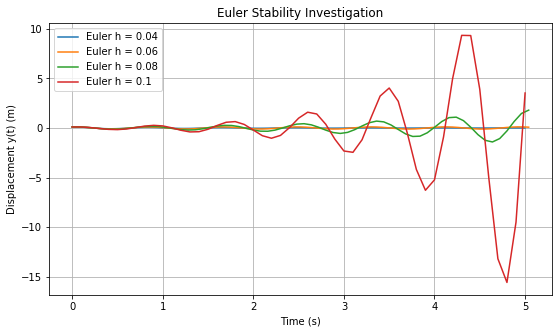

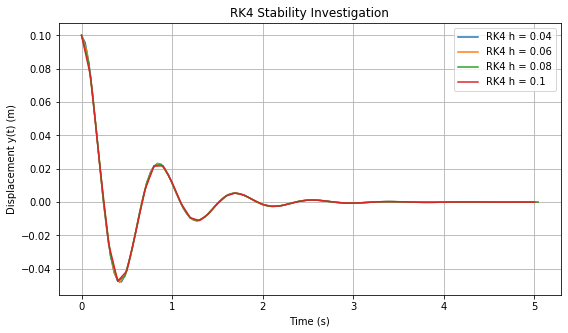

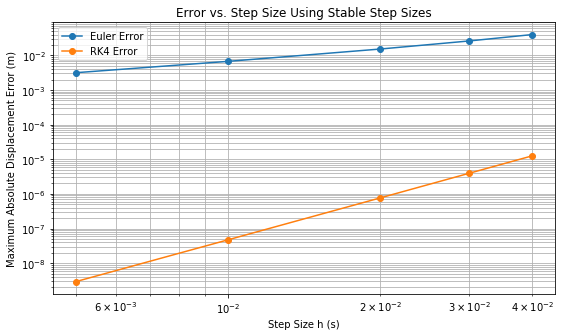

Euler convergence slope: 1.2122802665236025
RK4 convergence slope: 4.023771479664135


In [13]:
unstable_h_values = [0.04, 0.06, 0.08, 0.1]

plt.figure(figsize=(9, 5))

for h in unstable_h_values:
    t_euler, state_euler = euler_forward(suspension_rhs, t0, tf, h, initial_state)
    plt.plot(t_euler, state_euler[:, 0], label=f"Euler h = {h}")

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Euler Stability Investigation")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))

for h in unstable_h_values:
    t_rk4, state_rk4 = rk4(suspension_rhs, t0, tf, h, initial_state)
    plt.plot(t_rk4, state_rk4[:, 0], label=f"RK4 h = {h}")

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("RK4 Stability Investigation")
plt.legend()
plt.grid(True)
plt.show()

error_h_values = np.array([0.04, 0.03, 0.02, 0.01, 0.005])

euler_errors = []
rk4_errors = []

for h in error_h_values:
    t_euler, state_euler = euler_forward(suspension_rhs, t0, tf, h, initial_state)
    y_exact_euler, v_exact_euler = analytical_solution(t_euler)
    euler_error = np.max(np.abs(state_euler[:, 0] - y_exact_euler))
    euler_errors.append(euler_error)
    
    t_rk4, state_rk4 = rk4(suspension_rhs, t0, tf, h, initial_state)
    y_exact_rk4, v_exact_rk4 = analytical_solution(t_rk4)
    rk4_error = np.max(np.abs(state_rk4[:, 0] - y_exact_rk4))
    rk4_errors.append(rk4_error)

euler_errors = np.array(euler_errors)
rk4_errors = np.array(rk4_errors)

plt.figure(figsize=(9, 5))
plt.loglog(error_h_values, euler_errors, marker="o", label="Euler Error")
plt.loglog(error_h_values, rk4_errors, marker="o", label="RK4 Error")

plt.xlabel("Step Size h (s)")
plt.ylabel("Maximum Absolute Displacement Error (m)")
plt.title("Error vs. Step Size Using Stable Step Sizes")
plt.legend()
plt.grid(True, which="both")
plt.show()

euler_slope = np.polyfit(np.log(error_h_values), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(error_h_values), np.log(rk4_errors), 1)[0]

print("Euler convergence slope:", euler_slope)
print("RK4 convergence slope:", rk4_slope)


## 5. Stability Analysis

The stability investigation shows that Euler's Forward method is sensitive to the chosen step size. For this damped oscillating system, Euler’s method becomes unstable when the step size is too large. The stability limit depends on the eigenvalues of the system, which are determined by the mass, damping, and spring constants.

For linear systems, Euler’s method is stable only if the step size is small relative to the magnitude of the system eigenvalues. If the step size is too large, the method cannot accurately capture the fastest dynamics, leading to numerical instability.

From the numerical results, Euler’s method becomes unstable for step sizes larger than approximately \( h \approx 0.05 \) seconds. This observation is based on the plotted solutions, where larger step sizes produce oscillations that grow instead of decay.

In contrast, RK4 remains stable for larger step sizes due to its higher-order accuracy and larger stability region. This allows RK4 to produce accurate results with fewer steps, making it more efficient and reliable for this problem.

The error plot compares the numerical solution to the analytical solution using stable step sizes. Euler’s method shows first-order accuracy, while RK4 shows fourth-order accuracy, consistent with theory. Only stable Euler step sizes were used to avoid distortion of the convergence results.

Physically, instability appears as artificial growth in displacement, even though the damped system should lose energy over time. A stable numerical method should show oscillations that decay toward zero, matching the expected physical behavior.

## 6. Conclusions

For this spring-mass vehicle suspension model, RK4 performed better than Euler’s Forward method. Euler’s method was easier to implement, but it required a much smaller step size to remain stable and accurate. RK4, while slightly more computationally expensive per step, produced significantly more accurate results for the same step sizes.

The convergence results confirmed that Euler’s method is first-order accurate, while RK4 is fourth-order accurate. This explains why RK4 can achieve high accuracy without requiring extremely small step sizes.

The stability analysis showed that Euler’s method becomes unstable when the step size is too large, producing non-physical results such as growing oscillations. In contrast, RK4 remained stable for larger step sizes and maintained physically meaningful behavior.

Overall, this project demonstrates that both accuracy and stability are critical when choosing a numerical method. A method that is unstable or inaccurate can produce misleading results, even if the underlying model is correct.

##  References

Chapra, S. C., & Canale, R. P. (2015). *Numerical Methods for Engineers* (7th ed.). McGraw-Hill Education.

Burden, R. L., & Faires, J. D. (2011). *Numerical Analysis* (9th ed.). Brooks/Cole.

Boylestad, R. L. (2015). *Introductory Circuit Analysis* (13th ed.). Pearson.

COE 311K Lecture Notes. (2026). The University of Texas at Austin.